# Airline Route Data Preprocessing & Exploratory Data Analysis
### INFO 583 — Assignment 1 | Southwest Airlines Consulting Case
**Author:** Aketch Adhiambo Okoth  
**Course:** INFO 583 — Data Mining for Business  
**Institution:** Montclair State University  

---

## Business Context
You work for an analytics consulting firm hired by **Southwest Airlines**. You are given a dataset of airline routes and tasked with preprocessing and exploring the data.

The dataset `Airfares2.csv` contains **638 airline routes** with 18 variables covering route endpoints, market characteristics, airline presence, and fare information.

| Variable | Type | Description |
|---|---|---|
| S_CODE | Categorical | Starting airport code |
| S_CITY | Categorical | Starting city |
| E_CODE | Categorical | Ending airport code |
| E_CITY | Categorical | Ending city |
| COUPON | Numerical | Average coupons for the route |
| NEW | Numerical | Number of new carriers entering the route |
| VACATION | Categorical | Is this a vacation route? (Yes/No) |
| SW | Categorical | Does Southwest serve this route? (Yes/No) |
| HI | Numerical | Herfindahl Index (market concentration) |
| S_INCOME | Numerical | Starting city average personal income |
| E_INCOME | Numerical | Ending city average personal income |
| S_POP | Numerical | Starting city population |
| E_POP | Numerical | Ending city population |
| SLOT | Categorical | Airport slot constraints (Controlled/Free) |
| GATE | Categorical | Airport gate constraints (Constrained/Free) |
| DISTANCE | Numerical | Miles between endpoint airports |
| PAX | Numerical | Number of passengers on the route |
| FARE | Numerical | Average fare for the route |

---

In [1]:
# @title Full Name { run: "auto" }
Name = 'AKETCH ADHIAMBO OKOTH' # @param {type:"string", placeholder:"Enter Full Name"}
print("Author:", Name)

Author: AKETCH ADHIAMBO OKOTH


---
## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
from sklearn import set_config
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer
from sklearn.preprocessing import KBinsDiscretizer, LabelBinarizer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

set_config(transform_output='pandas')

# Display settings for clean outputs
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Question 1 — Data Loading, Inspection & Type Conversion

### 1(a) — Load dataset and view first 5 observations

In [3]:
# Load the dataset
data = pd.read_csv('Airfares2.csv')

print(f'Dataset shape: {data.shape[0]} rows × {data.shape[1]} columns')
print()
data.head()

Dataset shape: 638 rows × 18 columns



,S_CODE,S_CITY,E_CODE,E_CITY,COUPON,NEW,VACATION,SW,HI,S_INCOME,E_INCOME,S_POP,E_POP,SLOT,GATE,DISTANCE,PAX,FARE
0,*,Dallas/Fort Worth TX,*,Amarillo TX,1.0000,3.0000,No,Yes,5291.9900,28637,21112,3036732,205711.0000,Free,Free,312.0000,7864,64.1100
1,*,Atlanta GA,*,Baltimore/Wash Intl MD,1.0600,3.0000,No,No,5419.1600,26993,29838,3532657,7145897.0000,Free,Free,576.0000,8820,174.4700
2,*,Boston MA,*,Baltimore/Wash Intl MD,1.0600,3.0000,No,No,9185.2800,30124,29838,5787293,7145897.0000,Free,Free,364.0000,6452,207.7600
3,ORD,Chicago IL,*,Baltimore/Wash Intl MD,1.0600,3.0000,No,Yes,2657.3500,29260,29838,7830332,7145897.0000,Controlled,Free,612.0000,25144,85.4700
4,MDW,Chicago IL,*,Baltimore/Wash Intl MD,1.0600,3.0000,No,Yes,2657.3500,29260,29838,7830332,7145897.0000,Free,Free,612.0000,25144,85.4700


### 1(b) — View dataframe information and check for missing values

In [4]:
# Dataframe structure overview
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   S_CODE    638 non-null    object 
 1   S_CITY    638 non-null    object 
 2   E_CODE    638 non-null    object 
 3   E_CITY    638 non-null    object 
 4   COUPON    637 non-null    float64
 5   NEW       632 non-null    float64
 6   VACATION  636 non-null    object 
 7   SW        637 non-null    object 
 8   HI        638 non-null    float64
 9   S_INCOME  638 non-null    int64  
 10  E_INCOME  638 non-null    int64  
 11  S_POP     638 non-null    int64  
 12  E_POP     637 non-null    float64
 13  SLOT      635 non-null    object 
 14  GATE      638 non-null    object 
 15  DISTANCE  637 non-null    float64
 16  PAX       638 non-null    int64  
 17  FARE      636 non-null    float64
dtypes: float64(6), int64(4), object(8)
memory usage: 89.8+ KB


In [5]:
# Count missing values per column
missing = data.isnull().sum()
missing_pct = (data.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
print('Columns with missing values:')
print(missing_summary)

Columns with missing values:
          Missing Count  Missing (%)
COUPON                1       0.1600
NEW                   6       0.9400
VACATION              2       0.3100
SW                    1       0.1600
E_POP                 1       0.1600
SLOT                  3       0.4700
DISTANCE              1       0.1600
FARE                  2       0.3100


In [6]:
# Use MissingIndicator to flag rows with missing values
miss = MissingIndicator()
miss_id = miss.fit_transform(data)

# Show which columns have missing flags
print('Features flagged by MissingIndicator:')
print(miss.features_)
print()
print('Column names with missing values:')
print(data.columns[miss.features_].tolist())

Features flagged by MissingIndicator:
[ 4  5  6  7 12 13 15 17]

Column names with missing values:
['COUPON', 'NEW', 'VACATION', 'SW', 'E_POP', 'SLOT', 'DISTANCE', 'FARE']


**Answer 1(b):**

Yes, missing values are present. The following columns contain null entries:

| Column | Missing Count | Missing % |
|---|---|---|
| COUPON | 1 | 0.16% |
| NEW | 6 | 0.94% |
| VACATION | 2 | 0.31% |
| SW | 1 | 0.16% |
| E_POP | 1 | 0.16% |
| SLOT | 3 | 0.47% |
| DISTANCE | 1 | 0.16% |
| FARE | 2 | 0.31% |

All missingness rates are below 1%, indicating a small but non-trivial data quality issue that should be addressed before modeling.

### 1(c) — Identify variable types and convert categorical columns

In [7]:
# Identify variable types before conversion
print('Variable types before conversion:')
print(data.dtypes)
print()

# Categorical variables (object type): S_CODE, S_CITY, E_CODE, E_CITY, VACATION, SW, SLOT, GATE
# Numerical variables (int/float): COUPON, NEW, HI, S_INCOME, E_INCOME, S_POP, E_POP, DISTANCE, PAX, FARE

categorical_cols = ['S_CODE', 'S_CITY', 'E_CODE', 'E_CITY', 'VACATION', 'SW', 'SLOT', 'GATE']

# Convert object columns to proper 'category' dtype
data[categorical_cols] = data[categorical_cols].astype('category')

print('Conversion complete.')

Variable types before conversion:
S_CODE       object
S_CITY       object
E_CODE       object
E_CITY       object
COUPON      float64
NEW         float64
VACATION     object
SW           object
HI          float64
S_INCOME      int64
E_INCOME      int64
S_POP         int64
E_POP       float64
SLOT         object
GATE         object
DISTANCE    float64
PAX           int64
FARE        float64
dtype: object

Conversion complete.


In [8]:
# Extract variable arrays by type
cat_vars = data.select_dtypes(include='category').columns.tolist()
num_vars = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical Variables:', cat_vars)
print()
print('Numerical Variables:', num_vars)

Categorical Variables: ['S_CODE', 'S_CITY', 'E_CODE', 'E_CITY', 'VACATION', 'SW', 'SLOT', 'GATE']

Numerical Variables: ['COUPON', 'NEW', 'HI', 'S_INCOME', 'E_INCOME', 'S_POP', 'E_POP', 'DISTANCE', 'PAX', 'FARE']


In [9]:
# Confirm dtypes after conversion
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   S_CODE    638 non-null    category
 1   S_CITY    638 non-null    category
 2   E_CODE    638 non-null    category
 3   E_CITY    638 non-null    category
 4   COUPON    637 non-null    float64 
 5   NEW       632 non-null    float64 
 6   VACATION  636 non-null    category
 7   SW        637 non-null    category
 8   HI        638 non-null    float64 
 9   S_INCOME  638 non-null    int64   
 10  E_INCOME  638 non-null    int64   
 11  S_POP     638 non-null    int64   
 12  E_POP     637 non-null    float64 
 13  SLOT      635 non-null    category
 14  GATE      638 non-null    category
 15  DISTANCE  637 non-null    float64 
 16  PAX       638 non-null    int64   
 17  FARE      636 non-null    float64 
dtypes: category(8), float64(6), int64(4)
memory usage: 61.2 KB


**Answer 1(c):**

- **Categorical variables** (converted from `object` to `category`): `S_CODE`, `S_CITY`, `E_CODE`, `E_CITY`, `VACATION`, `SW`, `SLOT`, `GATE`
- **Numerical variables** (remain as `int64` or `float64`): `COUPON`, `NEW`, `HI`, `S_INCOME`, `E_INCOME`, `S_POP`, `E_POP`, `DISTANCE`, `PAX`, `FARE`

Converting categorical variables from `object` to `category` reduces memory usage and makes downstream processing with pandas and scikit-learn more efficient.

---

## Question 2 — Descriptive Statistics & Distributions

### 2(a) — Descriptive statistics for numerical variables

In [10]:
# Descriptive statistics for all numerical variables
data.describe()

,COUPON,NEW,HI,S_INCOME,E_INCOME,S_POP,E_POP,DISTANCE,PAX,FARE
count,637.0000,632.0000,638.0000,638.0000,638.0000,638.0000,637.0000,637.0000,638.0000,636.0000
mean,1.2025,2.7753,4442.1411,27759.8605,27663.7273,4557004.4875,3192517.7896,973.4066,12782.2147,160.7496
std,0.2039,0.7233,1724.2671,3596.2078,4611.3250,3010985.2648,2737293.6982,644.2511,13202.2289,75.9618
min,1.0000,0.0000,1230.4800,14600.0000,14600.0000,29838.0000,111745.0000,114.0000,1504.0000,42.4700
25%,1.0400,3.0000,3090.1375,24706.0000,23903.0000,1862106.0000,1228816.0000,455.0000,5328.5000,106.2450
50%,1.1500,3.0000,4208.1850,28637.0000,26409.0000,3532657.0000,2195215.0000,846.0000,7792.0000,144.6000
75%,1.3000,3.0000,5480.5750,29693.5000,31981.0000,7830332.0000,4549784.0000,1301.0000,14090.5000,209.3500
max,1.9400,3.0000,10000.0000,38813.0000,38813.0000,9056076.0000,9056076.0000,2764.0000,73892.0000,402.0200


### 2(b) — Descriptive statistics for categorical variables

In [11]:
# Descriptive statistics for categorical variables
data.describe(include='category')

,S_CODE,S_CITY,E_CODE,E_CITY,VACATION,SW,SLOT,GATE
count,638,638,638,638,636,637,635,638
unique,8,51,8,68,2,2,2,2
top,*,Chicago IL,*,New York/Newark NY,No,No,Free,Free
freq,454,90,501,75,466,443,454,514


### 2(c) — Distribution of the FARE variable

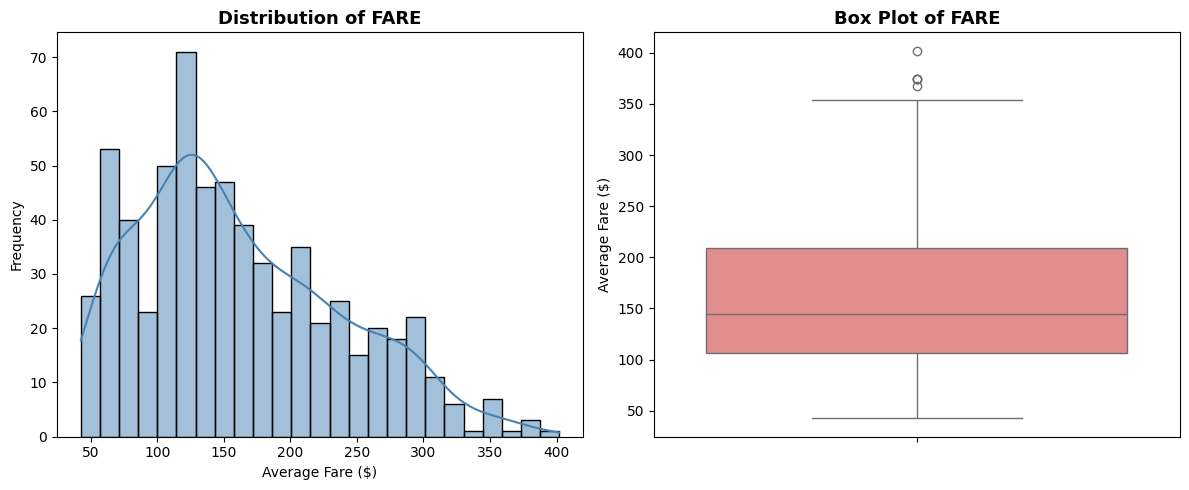

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram with KDE
sns.histplot(data['FARE'].dropna(), bins=25, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of FARE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Fare ($)')
axes[0].set_ylabel('Frequency')

# Box plot
sns.boxplot(y=data['FARE'].dropna(), color='lightcoral', ax=axes[1])
axes[1].set_title('Box Plot of FARE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Fare ($)')

plt.tight_layout()
plt.savefig('fare_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2(d) — Describe the shape of the FARE variable

In [13]:
skewness = data['FARE'].skew()
kurtosis = data['FARE'].kurt()

print(f'Skewness : {skewness:.4f}')
print(f'Kurtosis : {kurtosis:.4f}')
print()
print(f'Mean     : ${data["FARE"].mean():.2f}')
print(f'Median   : ${data["FARE"].median():.2f}')
print(f'Std Dev  : ${data["FARE"].std():.2f}')

Skewness : 0.6242
Kurtosis : -0.3213

Mean     : $160.75
Median   : $144.60
Std Dev  : $75.96


**Answer 2(d):**

The `FARE` variable is **positively skewed** (skewness ≈ +0.62), meaning that the majority of fares cluster at lower to mid-range values, with a long right tail pulled by a small number of high-fare routes. The mean is greater than the median, which is a classic signature of right skew.

The slightly negative kurtosis (≈ −0.32) indicates a **platykurtic** distribution — slightly flatter than a normal bell curve, with lighter tails and fewer extreme outliers than a normal distribution would produce. The box plot confirms moderate spread with a few high-fare outliers visible above the upper fence.

### 2(e) — Distribution of the VACATION variable

/tmp/ipykernel_2399/1524039678.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


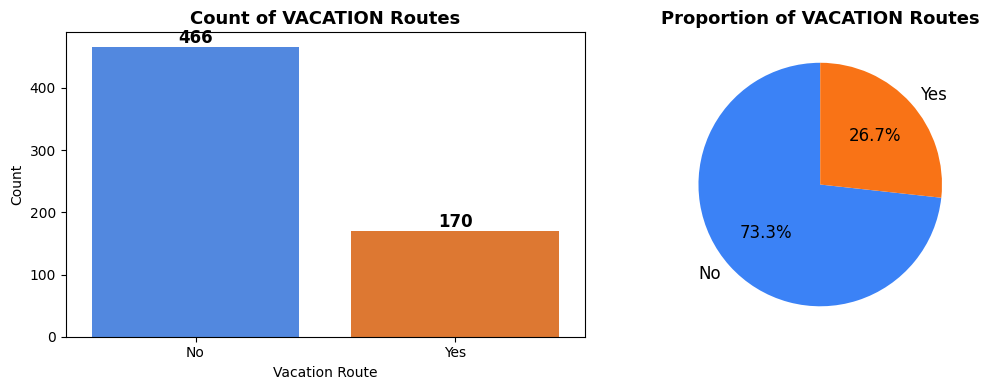

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count plot
vacation_counts = data['VACATION'].value_counts(dropna=True)
colors = ['#3B82F6', '#F97316']

sns.countplot(
    data=data.dropna(subset=['VACATION']),
    x='VACATION',
    palette={'No': '#3B82F6', 'Yes': '#F97316'},
    ax=axes[0],
    order=['No', 'Yes']
)
axes[0].set_title('Count of VACATION Routes', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Vacation Route')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(
    vacation_counts,
    labels=vacation_counts.index,
    autopct='%1.1f%%',
    colors=['#3B82F6', '#F97316'],
    startangle=90,
    textprops={'fontsize': 12}
)
axes[1].set_title('Proportion of VACATION Routes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('vacation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2(f) — Describe the distribution of the VACATION variable

In [15]:
counts  = data['VACATION'].value_counts(dropna=True)
percent = data['VACATION'].value_counts(normalize=True, dropna=True) * 100

print('VACATION — Counts:')
print(counts)
print()
print('VACATION — Percentages:')
print(percent.round(2))

VACATION — Counts:
VACATION
No     466
Yes    170
Name: count, dtype: int64

VACATION — Percentages:
VACATION
No    73.2700
Yes   26.7300
Name: proportion, dtype: float64


**Answer 2(f):**

The `VACATION` variable is a binary categorical variable with two categories. Of the 636 non-missing observations:
- **No** (non-vacation routes): 466 routes — 73.3%
- **Yes** (vacation routes): 170 routes — 26.7%

The distribution is **imbalanced**, with non-vacation routes outnumbering vacation routes by approximately 2.7 to 1. This class imbalance is important to account for if `VACATION` is used as a target variable in predictive modeling — techniques such as SMOTE oversampling or class-weight adjustments may be needed to prevent a model from being biased toward predicting the majority class.

---

## Question 3 — Missing Value Imputation & Normalization

### 3(a) — Impute missing values (median for numerical, mode for categorical)

> **Note:** This step addresses missing values through imputation, which is distinct from class imbalance handling. Imputation fills in gaps in the data so that no rows need to be dropped and all features remain available for analysis and modeling.

In [16]:
# BEFORE imputation: confirm missing counts
print('Missing values BEFORE imputation:')
print(data.isnull().sum()[data.isnull().sum() > 0])
print()

Missing values BEFORE imputation:
COUPON      1
NEW         6
VACATION    2
SW          1
E_POP       1
SLOT        3
DISTANCE    1
FARE        2
dtype: int64



In [17]:
#  Select column groups by correct dtype
# IMPORTANT: categorical columns were converted to dtype 'category' in Q1(c).
# We must use include='category', NOT include='object', to select them here.

num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include='category').columns  # ← correct dtype

print(f'Numerical columns to impute  ({len(num_cols)}): {num_cols.tolist()}')
print(f'Categorical columns to impute ({len(cat_cols)}): {cat_cols.tolist()}')

Numerical columns to impute  (10): ['COUPON', 'NEW', 'HI', 'S_INCOME', 'E_INCOME', 'S_POP', 'E_POP', 'DISTANCE', 'PAX', 'FARE']
Categorical columns to impute (8): ['S_CODE', 'S_CITY', 'E_CODE', 'E_CITY', 'VACATION', 'SW', 'SLOT', 'GATE']


In [18]:
#  Impute numerical columns with median
for col in num_cols:
    median_val = data[col].median()
    data[col] = data[col].fillna(median_val)

# Impute categorical columns with mode
# For 'category' dtype, mode() works correctly — we take the first mode value
for col in cat_cols:
    mode_val = data[col].mode()[0]
    data[col] = data[col].fillna(mode_val)

#  Confirm: no missing values remain
print('Missing values AFTER imputation:')
remaining = data.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else 'None — all missing values resolved.')
print()
data.info()

Missing values AFTER imputation:
None — all missing values resolved.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   S_CODE    638 non-null    category
 1   S_CITY    638 non-null    category
 2   E_CODE    638 non-null    category
 3   E_CITY    638 non-null    category
 4   COUPON    638 non-null    float64 
 5   NEW       638 non-null    float64 
 6   VACATION  638 non-null    category
 7   SW        638 non-null    category
 8   HI        638 non-null    float64 
 9   S_INCOME  638 non-null    int64   
 10  E_INCOME  638 non-null    int64   
 11  S_POP     638 non-null    int64   
 12  E_POP     638 non-null    float64 
 13  SLOT      638 non-null    category
 14  GATE      638 non-null    category
 15  DISTANCE  638 non-null    float64 
 16  PAX       638 non-null    int64   
 17  FARE      638 non-null    float64 
dtypes: category(8), floa

### 3(b) — Rescale numerical variables using Min-Max normalization

In [19]:
# Select numerical columns (post-imputation)
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Instantiate and apply Min-Max scaler
scaler = MinMaxScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

print('Min-Max normalization applied. All numerical values now scaled to [0, 1].')
print()
print('First 5 rows (numerical columns only):')
data[num_cols].head()

Min-Max normalization applied. All numerical values now scaled to [0, 1].

First 5 rows (numerical columns only):


,COUPON,NEW,HI,S_INCOME,E_INCOME,S_POP,E_POP,DISTANCE,PAX,FARE
0,0.0000,1.0000,0.4631,0.5797,0.2689,0.3331,0.0105,0.0747,0.0879,0.0602
1,0.0638,1.0000,0.4776,0.5118,0.6293,0.3881,0.7864,0.1743,0.1011,0.3671
2,0.0638,1.0000,0.9071,0.6411,0.6293,0.6379,0.7864,0.0943,0.0684,0.4597
3,0.0638,1.0000,0.1627,0.6055,0.6293,0.8642,0.7864,0.1879,0.3266,0.1196
4,0.0638,1.0000,0.1627,0.6055,0.6293,0.8642,0.7864,0.1879,0.3266,0.1196


In [20]:
# Verify that all numerical columns are now in [0, 1]
print('Range check — min and max of each numerical column after scaling:')
print(data[num_cols].agg(['min', 'max']).T.rename(columns={'min': 'Min', 'max': 'Max'}))

Range check — min and max of each numerical column after scaling:
            Min    Max
COUPON   0.0000 1.0000
NEW      0.0000 1.0000
HI       0.0000 1.0000
S_INCOME 0.0000 1.0000
E_INCOME 0.0000 1.0000
S_POP    0.0000 1.0000
E_POP    0.0000 1.0000
DISTANCE 0.0000 1.0000
PAX      0.0000 1.0000
FARE     0.0000 1.0000


**Min-Max normalization** rescales each numerical variable to the range [0, 1] using the formula: `X_scaled = (X − X_min) / (X_max − X_min)`. This ensures no single variable dominates distance-based or gradient-based models due to differences in scale.

---

## Question 4 — One-Hot Encoding of Categorical Variables

In [21]:
#  Identify categorical columns (dtype='category')
# IMPORTANT: must use include='category', not include='object'.
# At this stage all categorical columns have dtype='category' (set in Q1c).
cat_cols = data.select_dtypes(include='category').columns.tolist()

print(f'Categorical columns to encode ({len(cat_cols)}): {cat_cols}')
print(f'Dataframe shape before OHE : {data.shape}')

Categorical columns to encode (8): ['S_CODE', 'S_CITY', 'E_CODE', 'E_CITY', 'VACATION', 'SW', 'SLOT', 'GATE']
Dataframe shape before OHE : (638, 18)


In [22]:
#  Apply One-Hot Encoding
# pd.get_dummies handles 'category' dtype natively.
# drop_first=True drops the first dummy for each variable to avoid
# perfect multicollinearity (the dummy variable trap).

data_ohe = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print(f'Dataframe shape after OHE  : {data_ohe.shape}')
print(f'New columns added          : {data_ohe.shape[1] - (data.shape[1] - len(cat_cols))}')
print()
print('Last 5 rows of data_ohe:')
data_ohe.tail()

Dataframe shape after OHE  : (638, 145)
New columns added          : 135

Last 5 rows of data_ohe:


,COUPON,NEW,HI,S_INCOME,E_INCOME,S_POP,E_POP,DISTANCE,PAX,FARE,...,E_CITY_Tallahassee FL,E_CITY_Tampa FL,E_CITY_Tucson AZ,E_CITY_Tulsa OK,E_CITY_Washington DC,E_CITY_West Palm Beach FL,VACATION_Yes,SW_Yes,SLOT_Free,GATE_Free
633,0.0851,1.0000,0.1125,0.7596,0.9406,0.9518,0.0984,0.3457,0.4534,0.2424,...,False,False,False,False,False,True,True,False,False,True
634,0.0851,1.0000,0.1125,0.7596,0.9406,0.9518,0.0984,0.3457,0.4534,0.2424,...,False,False,False,False,False,True,True,False,True,False
635,0.1809,1.0000,0.6348,0.5532,0.9406,0.5449,0.0984,0.3192,0.0623,0.2292,...,False,False,False,False,False,True,True,False,True,True
636,0.2979,1.0000,0.4944,0.7178,0.9406,0.5008,0.0984,0.2808,0.0466,0.2424,...,False,False,False,False,False,True,True,False,True,True
637,0.2979,1.0000,0.4944,0.7178,0.9406,0.5008,0.0984,0.2808,0.0466,0.2424,...,False,False,False,False,False,True,True,False,False,True


In [23]:
# Preview all column names in the final encoded dataframe
print(f'Total features in data_ohe: {data_ohe.shape[1]}')
print()
print('All column names:')
for i, col in enumerate(data_ohe.columns, 1):
    print(f'  {i:3}. {col}')

Total features in data_ohe: 145

All column names:
    1. COUPON
    2. NEW
    3. HI
    4. S_INCOME
    5. E_INCOME
    6. S_POP
    7. E_POP
    8. DISTANCE
    9. PAX
   10. FARE
   11. S_CODE_DCA
   12. S_CODE_EWR
   13. S_CODE_IAD
   14. S_CODE_JFK
   15. S_CODE_LGA
   16. S_CODE_MDW
   17. S_CODE_ORD
   18. S_CITY_Anchorage           AK
   19. S_CITY_Atlanta             GA
   20. S_CITY_Austin              TX
   21. S_CITY_Baltimore/Wash Intl MD
   22. S_CITY_Boise               ID
   23. S_CITY_Boston              MA
   24. S_CITY_Burbank             CA
   25. S_CITY_Chicago             IL
   26. S_CITY_Cincinnati          OH
   27. S_CITY_Cleveland           OH
   28. S_CITY_Columbus            OH
   29. S_CITY_Corpus Christi      TX
   30. S_CITY_Dallas/Fort Worth   TX
   31. S_CITY_Denver              CO
   32. S_CITY_Detroit             MI
   33. S_CITY_El Paso             TX
   34. S_CITY_Fort Lauderdale     FL
   35. S_CITY_Fort Meyers         FL
   36. S_CITY_Greenville/

**Answer — Question 4:**

One-hot encoding converts each categorical variable into a set of binary (0/1) dummy columns, one per category level (minus one when `drop_first=True` to avoid the dummy variable trap). The resulting `data_ohe` dataframe contains:
- All 10 **normalized numerical** columns (from Q3b)
- All **binary dummy columns** generated from the 8 categorical variables

The expanded feature set is suitable for machine learning algorithms that require fully numerical input, such as Logistic Regression, SVM, or Neural Networks.

---

## Summary

This notebook completed the full data preprocessing pipeline for the Southwest Airlines route dataset:

| Step | Action | Result |
|---|---|---|
| 1. Loading | `pd.read_csv()` | 638 rows × 18 columns loaded |
| 2. Inspection | `.info()`, `.isnull().sum()` | 8 columns with missing values identified |
| 3. Type conversion | `.astype('category')` | 8 object columns converted to category dtype |
| 4. EDA | Histplot, boxplot, countplot, pie | FARE is right-skewed; VACATION is 73% No |
| 5. Imputation | Median (numerical), mode (categorical) | All missing values resolved |
| 6. Normalization | `MinMaxScaler` | All 10 numerical columns scaled to [0, 1] |
| 7. Encoding | `pd.get_dummies(drop_first=True)` | Categorical variables one-hot encoded |

The final `data_ohe` dataframe is fully preprocessed and ready for supervised or unsupervised machine learning tasks.